# 10. Gerçek Fotoğrafta Renk Sıkıştırma

**Kategori:** Bilgisayarlı Görü  
**Gerçek veri seti:** scikit-learn China sample photograph  
**Veri kaynağı:** [https://scikit-learn.org/stable/auto_examples/cluster/plot_color_quantization.html](https://scikit-learn.org/stable/auto_examples/cluster/plot_color_quantization.html)  
**Amaç:** Gerçek bir fotoğrafın renk paletini MiniBatch K-Means ile küçültmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Görüntü EDA'sı

Görüntü boyutu: (427, 640, 3) | Piksel sayısı: 273280


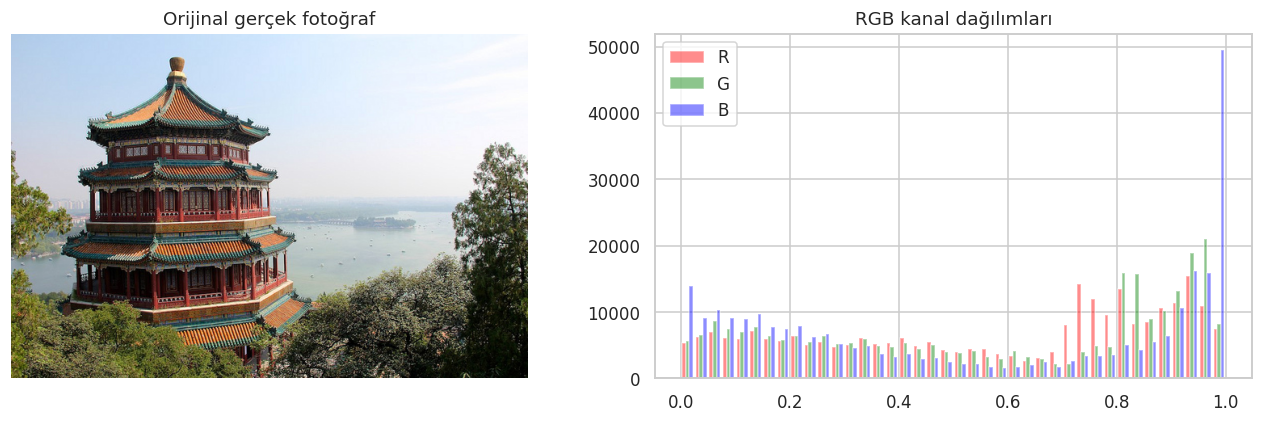

In [2]:
from sklearn.datasets import load_sample_image
image = load_sample_image("china.jpg")
pixels = image.reshape(-1, 3).astype("float32") / 255
print("Görüntü boyutu:", image.shape, "| Piksel sayısı:", len(pixels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image); axes[0].set_title("Orijinal gerçek fotoğraf"); axes[0].axis("off")
axes[1].hist(pixels, bins=40, color=["red", "green", "blue"], alpha=.45, label=["R", "G", "B"])
axes[1].set_title("RGB kanal dağılımları"); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. Renk paleti modeli

In [3]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import mean_squared_error

sample = pixels[::10]
palette_sizes = [8, 16, 32]
models = {k: MiniBatchKMeans(n_clusters=k, n_init=5, batch_size=4096,
                             random_state=RANDOM_STATE).fit(sample)
          for k in palette_sizes}
compressed = {k: models[k].cluster_centers_[models[k].predict(pixels)].reshape(image.shape)
              for k in palette_sizes}
evaluation = pd.Series({k: mean_squared_error(pixels, compressed[k].reshape(-1, 3))
                        for k in palette_sizes}, name="MSE")
display(evaluation.to_frame())

,MSE
8,0.003454
16,0.001861
32,0.001026


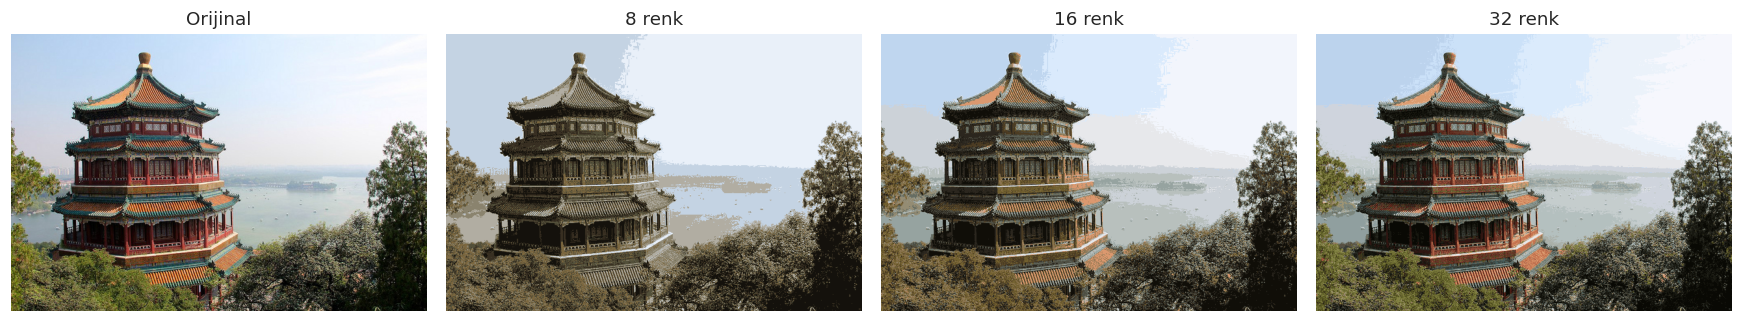

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image); axes[0].set_title("Orijinal")
for ax, k in zip(axes[1:], palette_sizes):
    ax.imshow(np.clip(compressed[k], 0, 1)); ax.set_title(f"{k} renk")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

selected_k = 16
joblib.dump({"model": models[selected_k], "palette_size": selected_k,
             "evaluation": evaluation.to_dict()}, MODEL_DIR / "10_renk_sikistirma.joblib")
json.dump({"palette_size": selected_k, "MSE": float(evaluation[selected_k])},
          open(RESULT_DIR / "10_renk_sikistirma.json", "w"), indent=2)

## Sonuç

Rastgele üretilmiş blok görüntü yerine gerçek bir fotoğraf kullanıldı. 8, 16 ve 32 renkli paletlerin
MSE değerleri ve görsel kalite farkı birlikte değerlendirildi. MSE düştükçe piksel benzerliği artar;
ancak dosya boyutu ve algısal kalite kararı yalnızca MSE ile verilmemelidir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **K-Means ile renk paletini azaltma** biçimindedir.
Bu notebookta **gerçek fotoğraf, üç palet boyutu, sayısal MSE ve yan yana görsel kalite karşılaştırması** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).